# Explore here

## Paso 1: Planteamiento del problema y recopilación de datos

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [214]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv', delimiter=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Paso 2: Exploración y limpieza de datos

In [215]:
df.shape

(41188, 21)

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [217]:
print("Observamos que no tiene ningun dato NaN. Procedemos a eliminar las columnas innecesarias.")

Observamos que no tiene ningun dato NaN. Procedemos a eliminar las columnas innecesarias.


In [218]:
df = df.drop(columns=['day_of_week', 'month'])

In [219]:
df.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Paso 3: Análisis de variables univariante

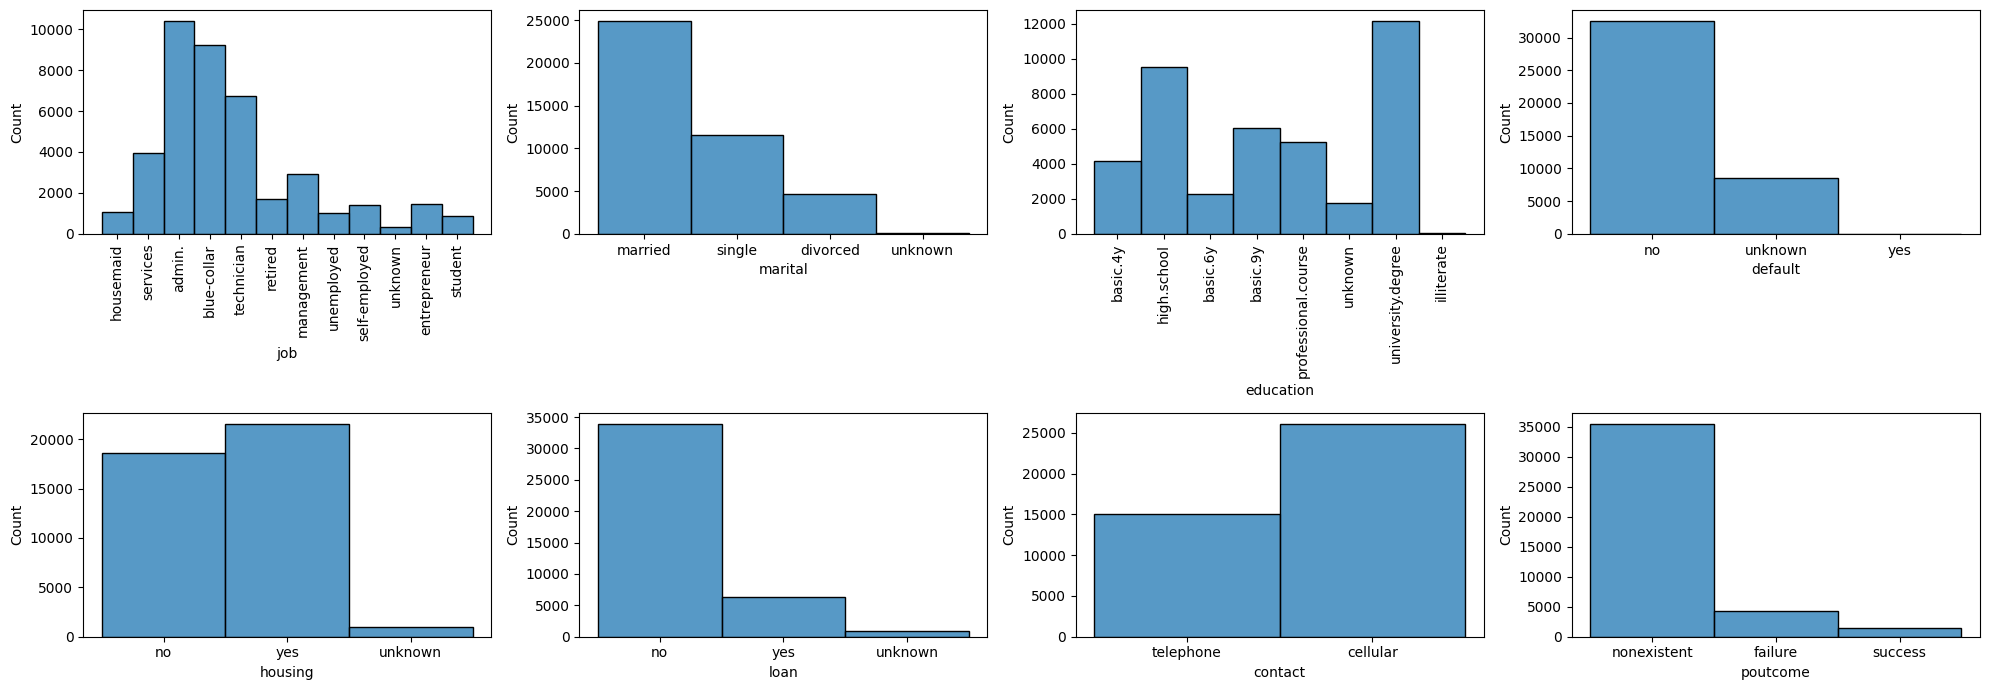

In [220]:
fig, axis = plt.subplots(2, 4, figsize = (20, 7))

axis[0, 0].tick_params(axis='x', rotation=90)
axis[0, 2].tick_params(axis='x', rotation=90)

sns.histplot(ax = axis[0, 0], data = df, x = "job")
sns.histplot(ax = axis[0, 1], data = df, x = "marital")
sns.histplot(ax = axis[0, 2], data = df, x = "education")
sns.histplot(ax = axis[0, 3], data = df, x = "default")
sns.histplot(ax = axis[1, 0], data = df, x = "housing")
sns.histplot(ax = axis[1, 1], data = df, x = "loan")
sns.histplot(ax = axis[1, 2], data = df, x = "contact")
sns.histplot(ax = axis[1, 3], data = df, x = "poutcome")

plt.tight_layout()
plt.show()

In [221]:
print("Tenemos 8 variables categoricas y 9 numericas")

Tenemos 8 variables categoricas y 9 numericas


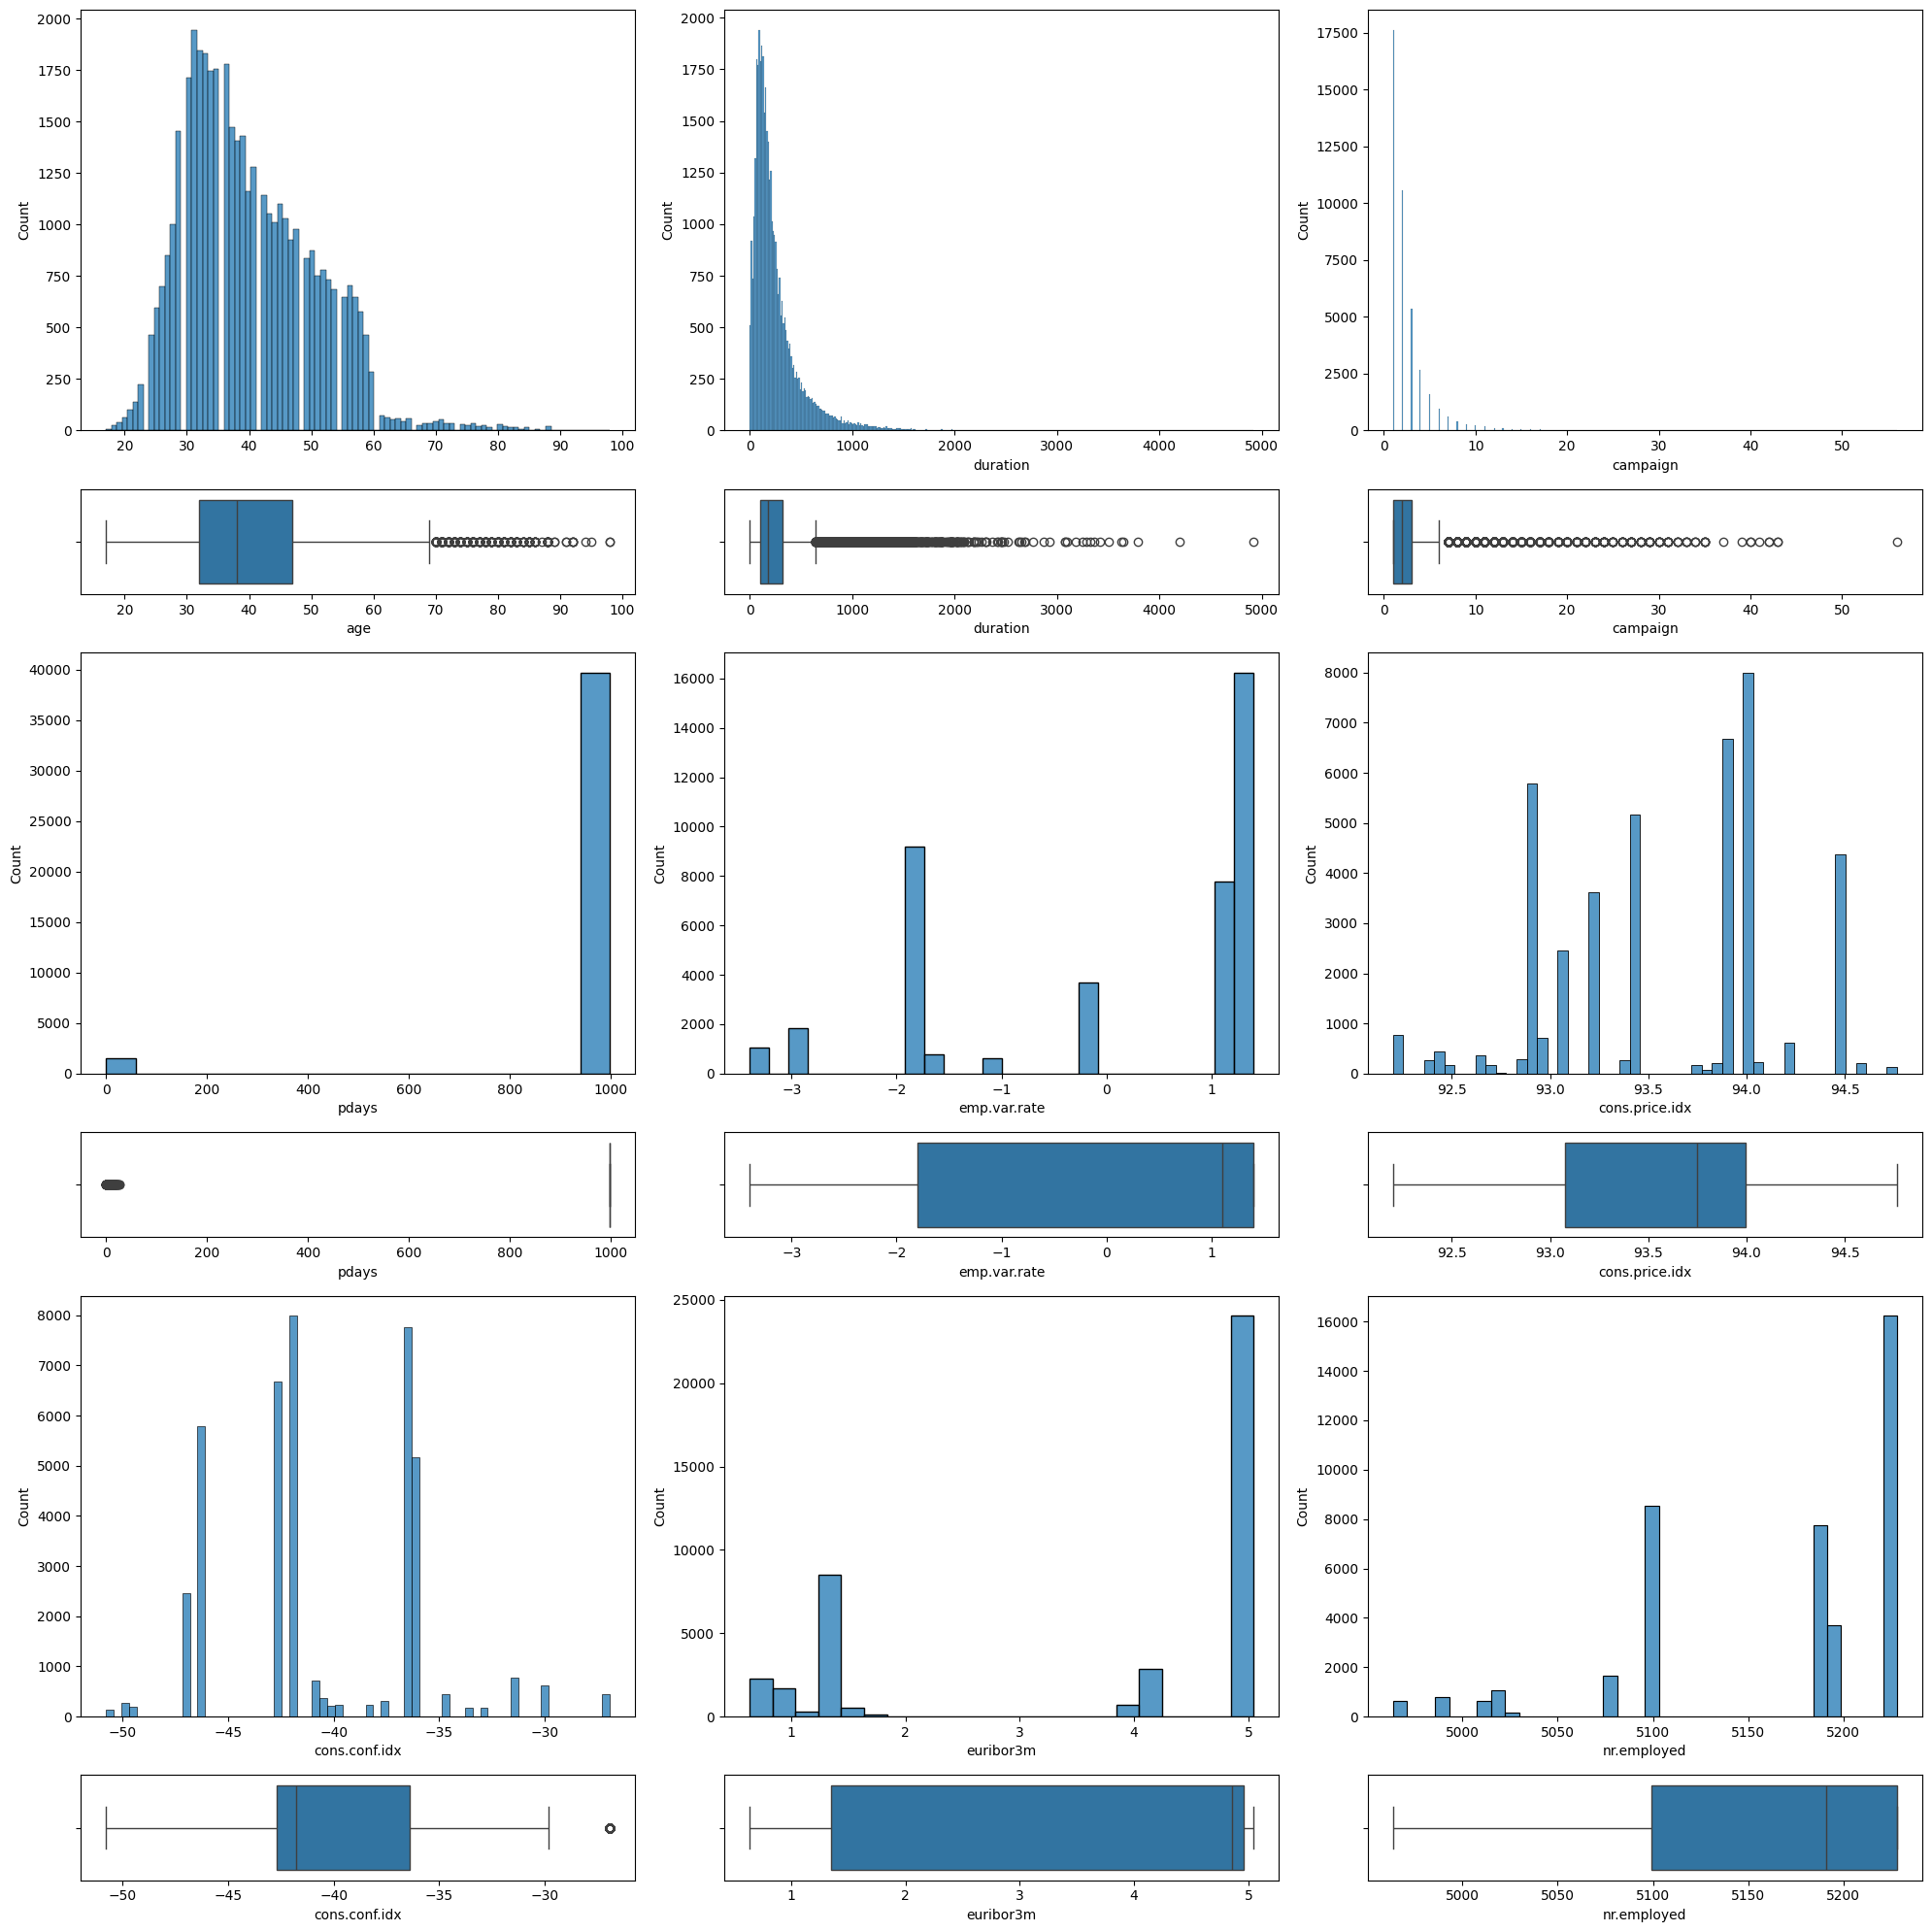

In [222]:
fig, axis = plt.subplots(6, 3, figsize = (20, 20), gridspec_kw={'height_ratios': [4, 1, 4, 1, 4, 1]})

sns.histplot(ax = axis[0, 0], data = df, x = "age").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "age")

sns.histplot(ax = axis[0, 1], data = df, x = "duration")
sns.boxplot(ax = axis[1, 1], data = df, x = "duration")

sns.histplot(ax = axis[0, 2], data = df, x = "campaign")
sns.boxplot(ax = axis[1, 2], data = df, x = "campaign")

sns.histplot(ax = axis[2, 0], data = df, x = "pdays")
sns.boxplot(ax = axis[3, 0], data = df, x = "pdays")

sns.histplot(ax = axis[2, 1], data = df, x = "emp.var.rate")
sns.boxplot(ax = axis[3, 1], data = df, x = "emp.var.rate")

sns.histplot(ax = axis[2, 2], data = df, x = "cons.price.idx")
sns.boxplot(ax = axis[3, 2], data = df, x = "cons.price.idx")

sns.histplot(ax = axis[4, 0], data = df, x = "cons.conf.idx")
sns.boxplot(ax = axis[5, 0], data = df, x = "cons.conf.idx")

sns.histplot(ax = axis[4, 1], data = df, x = "euribor3m")
sns.boxplot(ax = axis[5, 1], data = df, x = "euribor3m")

sns.histplot(ax = axis[4, 2], data = df, x = "nr.employed")
sns.boxplot(ax = axis[5, 2], data = df, x = "nr.employed")

plt.tight_layout()
plt.show()

## Paso 4: Análisis de variables multivariante

### Numerico-Numerico

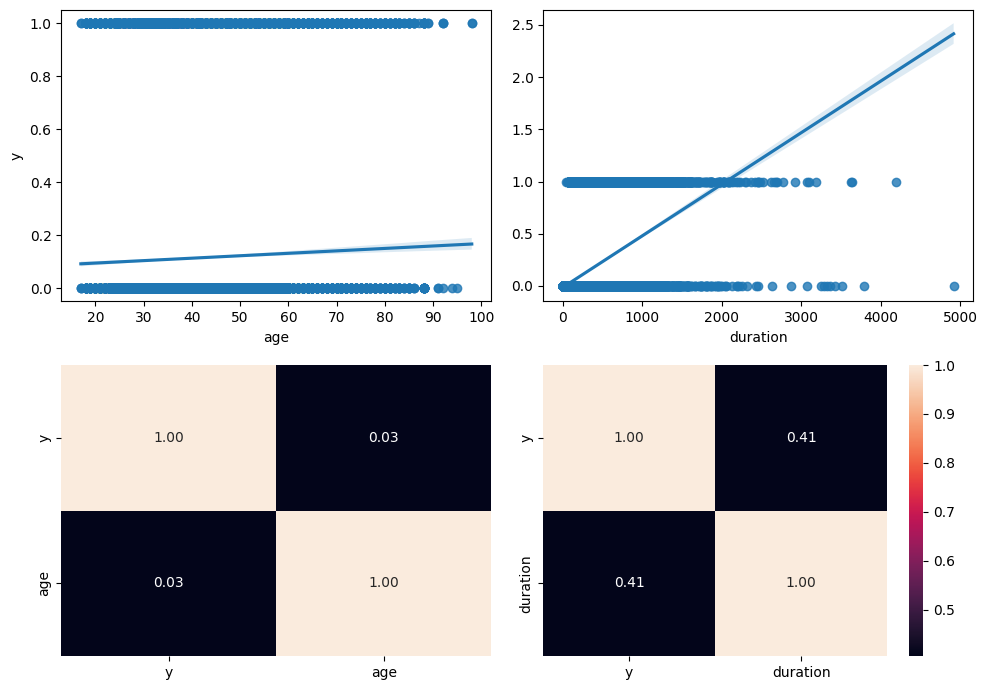

In [223]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

fig, axis = plt.subplots(2, 2, figsize = (10, 7))

sns.regplot(ax = axis[0, 0], data = df, x = "age", y = "y")
sns.heatmap(df[["y", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = df, x = "duration", y = "y").set(ylabel=None)
sns.heatmap(df[["y", "duration"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

plt.tight_layout()
plt.show()

### Categorico-Categorico

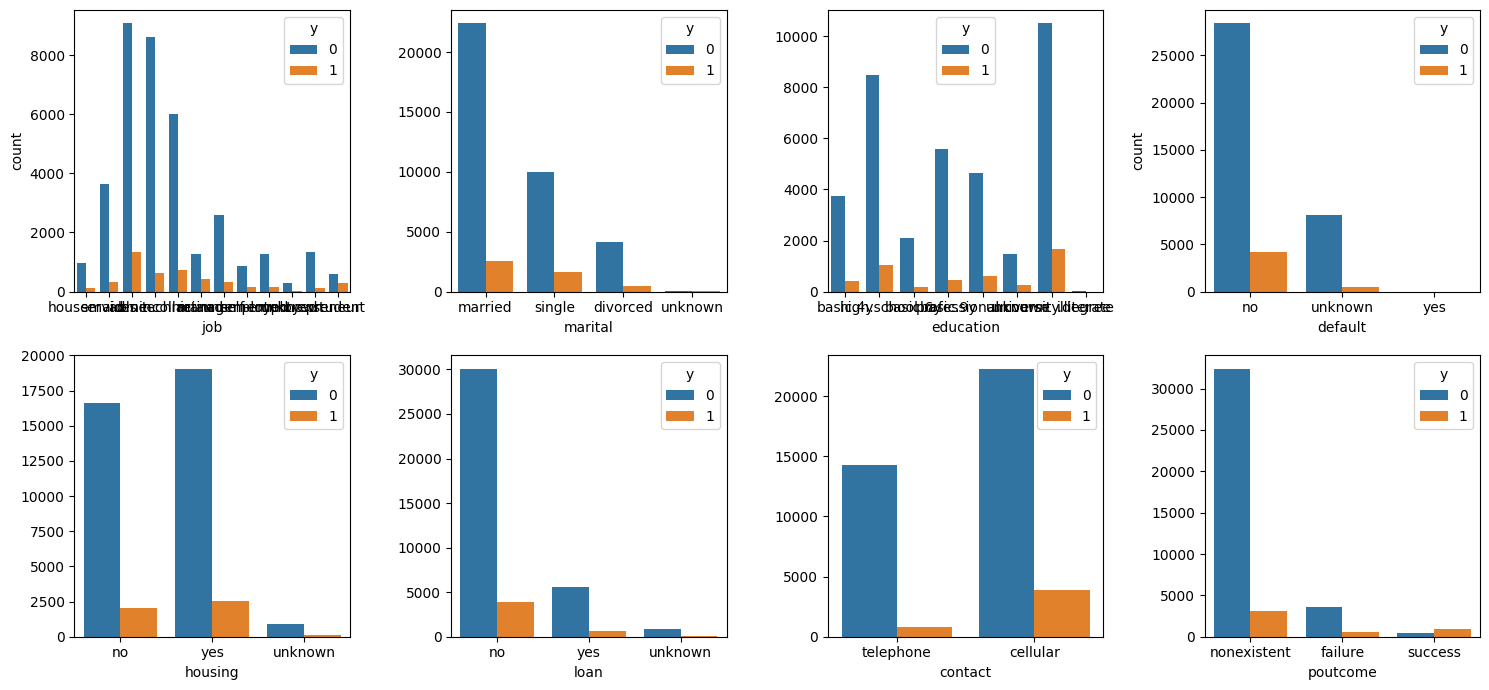

In [224]:
fig, axis = plt.subplots(2, 4, figsize = (15, 7))

sns.countplot(ax = axis[0, 0], data = df, x = "job", hue = "y")
sns.countplot(ax = axis[0, 1], data = df, x = "marital", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = df, x = "education", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 3], data = df, x = "default", hue = "y")
sns.countplot(ax = axis[1, 0], data = df, x = "housing", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 1], data = df, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = df, x = "contact", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 3], data = df, x = "poutcome", hue = "y").set(ylabel = None)

plt.tight_layout()
plt.show()

In [225]:
df["job_n"] = pd.factorize(df["job"])[0]
df["marital_n"] = pd.factorize(df["marital"])[0]
df["education_n"] = pd.factorize(df["education"])[0]
df["default_n"] = pd.factorize(df["default"])[0]
df["housing_n"] = pd.factorize(df["housing"])[0]
df["loan_n"] = pd.factorize(df["loan"])[0]
df["contact_n"] = pd.factorize(df["contact"])[0]
df["poutcome_n"] = pd.factorize(df["poutcome"])[0]

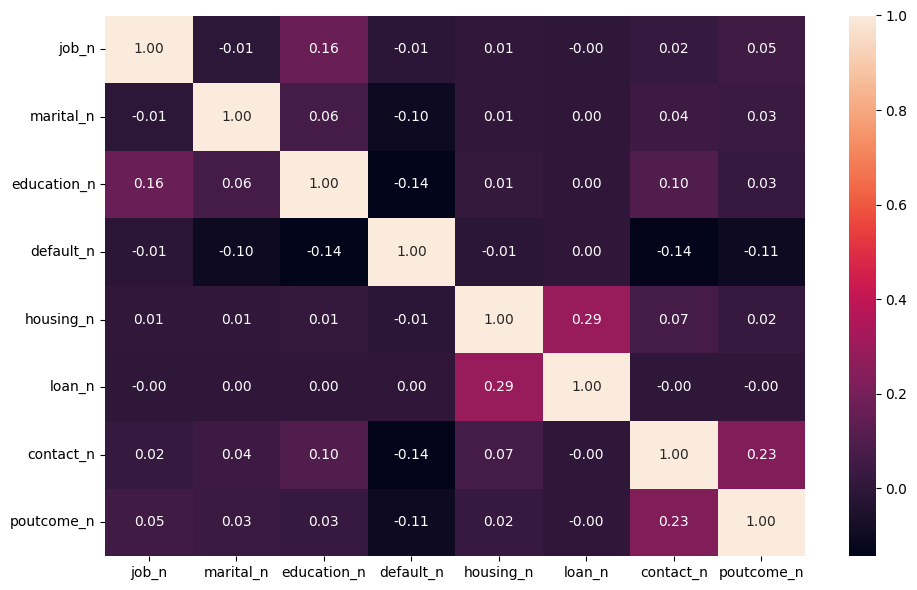

In [226]:
fig, axis = plt.subplots(figsize = (10, 6))

sns.heatmap(df[["job_n", "marital_n", "education_n", "default_n", "housing_n", "loan_n", "contact_n", "poutcome_n"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()
plt.show()

### Categorico-Numerico

In [227]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'job_n', 'marital_n', 'education_n', 'default_n',
       'housing_n', 'loan_n', 'contact_n', 'poutcome_n'],
      dtype='object')

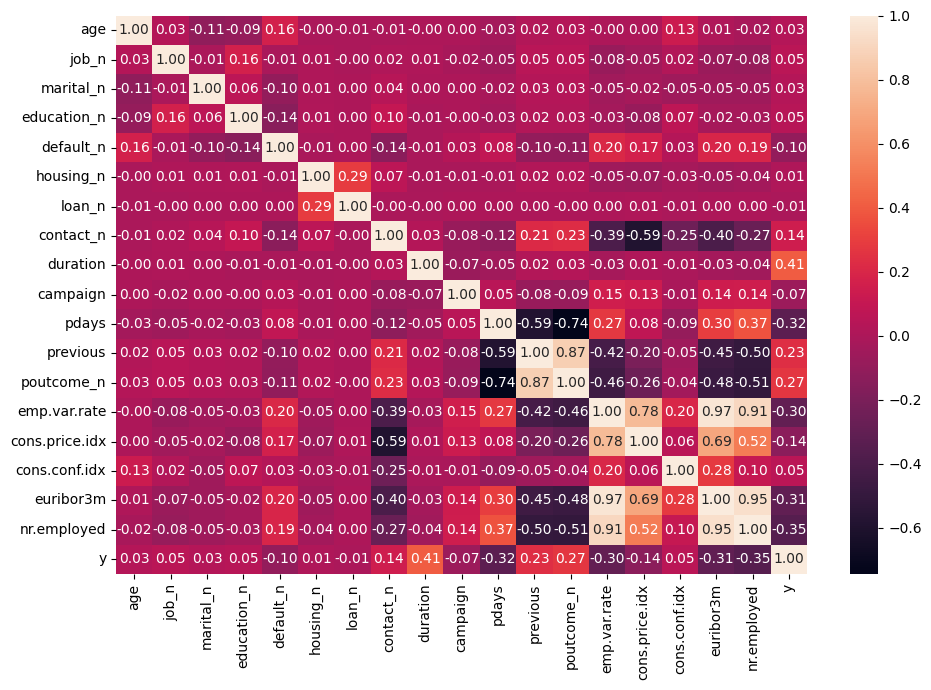

In [228]:
fig, axis = plt.subplots(figsize = (10, 7))

sns.heatmap(df[["age", "job_n", "marital_n", "education_n", "default_n", "housing_n", "loan_n", "contact_n",
                "duration", "campaign", "pdays", "previous", "poutcome_n", "emp.var.rate", "cons.price.idx",
                "cons.conf.idx", "euribor3m", "nr.employed", "y"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()
plt.show()

# Regresión Logística

In [237]:
num_variables = ["default_n", "contact_n", "duration", "pdays", "previous", "poutcome_n", "emp.var.rate", "cons.price.idx", "euribor3m", "nr.employed"]

X = df.drop("y", axis = 1)[num_variables]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

,default_n,contact_n,duration,pdays,previous,poutcome_n,emp.var.rate,cons.price.idx,euribor3m,nr.employed
12556,1,0,94,999,0,0,1.4,93.918,4.960,5228.1
35451,0,1,116,999,0,0,-1.8,92.893,1.244,5099.1
30592,0,1,13,999,1,1,-1.8,92.893,1.354,5099.1
17914,0,1,94,999,0,0,1.4,93.918,4.961,5228.1
3315,1,0,344,999,0,0,1.1,93.994,4.860,5191.0


In [238]:
model = LogisticRegression(max_iter=5000, penalty='l2', C=1)
model.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=5000)

In [239]:
"""model = LogisticRegression(max_iter=5000, class_weight='balanced')
model.fit(X_train, y_train)

Resultados: 
- Exactitud (Accuracy): 0.85

- Precisión: 0.43

- Recall: 0.86

- AUC: 0.93 """

"model = LogisticRegression(max_iter=5000, class_weight='balanced')\nmodel.fit(X_train, y_train)\n\nResultados: \n- Exactitud (Accuracy): 0.85\n\n- Precisión: 0.43\n\n- Recall: 0.86\n\n- AUC: 0.93 "

In [240]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [241]:
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

In [242]:
# Resultados
print(f'Exactitud: {accuracy:.2f}')
print(f'Precisión: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'AUC: {roc_auc:.2f}')

Exactitud: 0.91
Precisión: 0.66
Recall: 0.40
AUC: 0.93


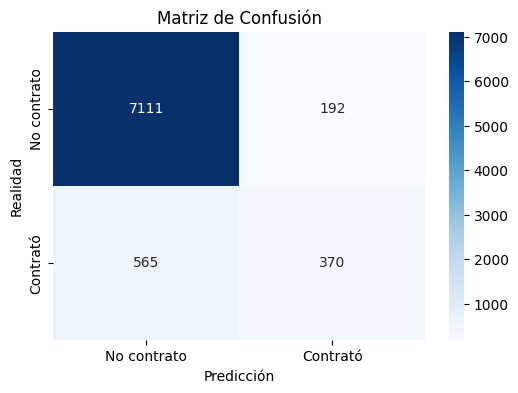

In [243]:
# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No contrato', 'Contrató'],
            yticklabels=['No contrato', 'Contrató'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

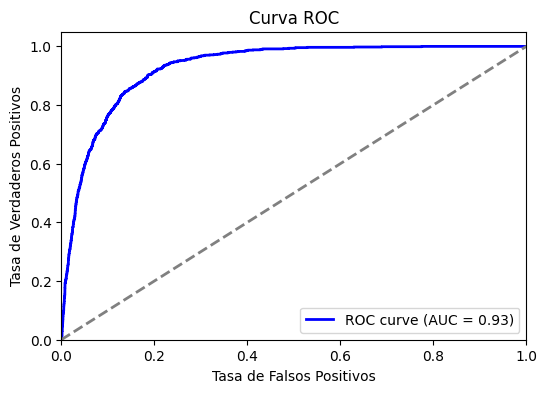

In [244]:
# Curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()